# Auditoría inicial del dataset

En este notebook se realiza una auditoría inicial del conjunto de datos utilizado en el proyecto. El objetivo es conocer su estructura, tipos de variables, calidad de los datos y posibles problemas que deberán ser tratados durante las fases posteriores de análisis exploratorio (EDA) y preprocesado.

El dataset utilizado se puede consultar en el siguiente enlace: https://www.kaggle.com/datasets/thedevastator/spanish-housing-dataset-location-size-price-and/data?select=spanish_houses.csv

## 1. Carga y descripción inicial del dataset

En esta primera fase se realiza una descripción general del conjunto de datos utilizado en el proyecto. El objetivo es conocer su dimensión, estructura, tipos de variables y características generales antes de comenzar con el análisis exploratorio y el preprocesado.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargamos el dataset
df = pd.read_csv("../data/raw/spanish_houses.csv")
df.head()

,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
0,Precio chalet individual en la localidad de Ab...,Anuncio actualizado el 27 de marzo,0,0,2,0,0,segunda mano/buen estado,NaN,NaN,...,4,0,0,1,NaN,19147,328868,0.57,0.7,19889.0
1,"Atico de 80m2, para entrar a vivir, con salón ...",más de 5 meses sin actualizar,0,0,2,0,0,segunda mano/buen estado,2006.0,no indicado,...,3,1,0,0,NaN,19147,328868,0.57,0.7,19889.0
2,B/ Etxaguen. Casa de reciente construcción con...,más de 5 meses sin actualizar,0,0,3,0,0,segunda mano/buen estado,NaN,no indicado,...,4,1,0,1,NaN,19147,328868,0.57,0.7,19889.0
3,Se vende vivienda en abornikano (ayuntamiento ...,más de 5 meses sin actualizar,0,1,1,1,1,segunda mano/buen estado,NaN,en trámite,...,4,1,0,1,NaN,19147,328868,0.57,0.7,19889.0
4,Negociables.,más de 5 meses sin actualizar,0,0,1,0,0,segunda mano/buen estado,NaN,no indicado,...,2,1,1,1,NaN,19147,328868,0.57,0.7,19889.0


In [4]:
# Número de filas y columnas
df.shape

(100000, 41)

El conjunto de datos está compuesto por 100000 resgistros y 41 variables. Los registros corresponden a anuncios de viviendas e incluyen información relacionada con sus características, localización y determinadas variables socioeconómicas, además del precio del inmueble.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ad_description                 95426 non-null   object 
 1   ad_last_update                 100000 non-null  object 
 2   air_conditioner                100000 non-null  object 
 3   balcony                        100000 non-null  object 
 4   bath_num                       100000 non-null  object 
 5   built_in_wardrobe              100000 non-null  object 
 6   chimney                        100000 non-null  object 
 7   condition                      86059 non-null   object 
 8   construct_date                 32059 non-null   object 
 9   energetic_certif               74691 non-null   object 
 10  floor                          79693 non-null   object 
 11  garage                         40811 non-null   object 
 12  garden                         

La información estructural muestra que la mayoría de las variables se encuentran almacenadas inicialmente como objetos ('object'). Algunas de ellas representan variables que, por su naturaleza, deberían ser numéricas, como el precio, la superficie o el número de habitaciones y baños.

Se analizará esta cuestión a lo largo de la auditoría en puntos posteriores.

In [34]:
# Usamos describe con include="all", ya que ahora mismo tenemos 36 variables 'object' y queremos una descripción de todas ellas no solo de las variables numéricas
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ad_description,95426,86150,ad_description,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_last_update,100000,369,más de 5 meses sin actualizar,3208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
air_conditioner,100000,3,0,76867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balcony,100000,3,0,81668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath_num,100000,30,2,40556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
built_in_wardrobe,100000,3,0,57444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chimney,100000,3,0,96132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,86059,4,segunda mano/buen estado,72272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
construct_date,32059,355,2007,1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energetic_certif,74691,4,en trámite,46957,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Conclusiones iniciales

El conjunto de datos está compuesto por 100000 registros y 41 variables. La información presenta una combinación de variables numéricas y categóricas, aunque una parte importante de las variables se encuentra inicialmente almacenada como texto.

La exploración inicial permite identificar algunas características que requerirán un análisis posterior más detallado. Entre ellas destacan la presencia de valores ausentes en numerosas variables, la elevada cardinalidad de algunas variables relacionadas con la localización y la existencia de determinadas variables que, pese a representar características numéricas, están almacenadas como texto.

También se observan algunos valores potencialmente anómalos, como la aparición  del propio nombre de la variable como valor de determinados campos. Se harán comprobaciones al respecto en los apartados siguientes antes de proceder al análisis exploratorio y al preprocesado.

Por último, algunas variables presentan una elevada proporción de valores ausentes, por lo que será necesario determinar posteriormente si estos valores responden a información no proporcionada o a problemas en la fuente de datos.

## 2. Estructura y tipos de datos.

In [35]:
# Contar columnas de cada tipo
df.dtypes.value_counts()

object     36
float64     3
int64       2
Name: count, dtype: int64

In [38]:
# Variables potencialmente numéricas

possible_numeric = [
    "bath_num",
    "construct_date",
    "m2_real",
    "m2_useful",
    "price",
    "room_num"
]

for col in possible_numeric:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts(dropna=False).head(15))


bath_num
bath_num
2            40556
1            37222
3            13120
4             5056
5             1828
6              773
sin baños      670
7              266
bath_num       183
8              120
9               66
10              44
11              23
13              17
12              15
Name: count, dtype: int64

construct_date
construct_date
NaN     67941
2007     1031
2008     1017
2006      967
2005      857
2000      856
1900      830
1970      796
2002      666
1980      663
2003      655
2009      619
2004      619
2010      574
1960      565
Name: count, dtype: int64

m2_real
m2_real
90     3218
80     3012
100    2961
70     2667
75     2130
120    1997
60     1989
110    1981
85     1954
65     1746
95     1571
200    1277
150    1182
140    1110
105    1090
Name: count, dtype: int64

m2_useful
m2_useful
NaN     47156
90       1453
100      1155
80       1064
70        991
70.0      858
90.0      826
60        780
85        747
120       731
75        726
80.0 

### Conclusiones

El dataset contiene 41 variables, de las cuales 36 están almacenadas inicialmente como `object` y únicamente 5 presentan tipos numéricos (`int64` o `float64`). La inspección de los valores permite comprobar que varias variables almacenadas como texto representan realmente magnitudes numéricas, como por ejemplo: `bath_num`, `construct_date`, `m2_real`, `m2_useful`, `price` y `room_num`.

Además, se han identificado determinadas categorías o valores textuales que deberían ser tratados durante el preprocesado. En concreto, las variables `bath_num` y `room_num` contienen los valores "sin baños" y "sin habitación", mientras que ambas presentan también registros en los que aparece el propio nombre de la variable como valor. Este último comportamiento se observa para otras variables del dataset y será analiza con mayor detalle en las comprobaciones de calidad de datos.

Por otro lado, `m2_useful` presenta valores equivalentes almacenados con distintos formatos, como `90` y `90.0`, que deberán homogeneizarse.

Por lo tanto, los tipos de datos originales no reflejan completamente la naturaleza de las variables. Durante el preprocesado será necesario revisar y transformar las variables númericas almacenadas como texto, así como tratar los valores anómalos identificados. Las variables categóricas y de localización se mantendrán como están y recibirán un tratamiento específico en función del algoritmo de aprendizaje que se emplee más adelante.

## 3. Valores ausentes

In [41]:
missing_summary = pd.DataFrame({
    "num_missing": df.isnull().sum(),
    "porcentaje_missing": df.isnull().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["num_missing"] > 0]
    .sort_values("porcentaje_missing", ascending=False)
)

missing_summary

,num_missing,porcentaje_missing
ground_size,99817,99.817
unfurnished,99354,99.354
kitchen,97788,97.788
loc_street,85686,85.686
heating,74286,74.286
construct_date,67941,67.941
orientation,60585,60.585
garage,59189,59.189
loc_neigh,56310,56.310
m2_useful,47156,47.156


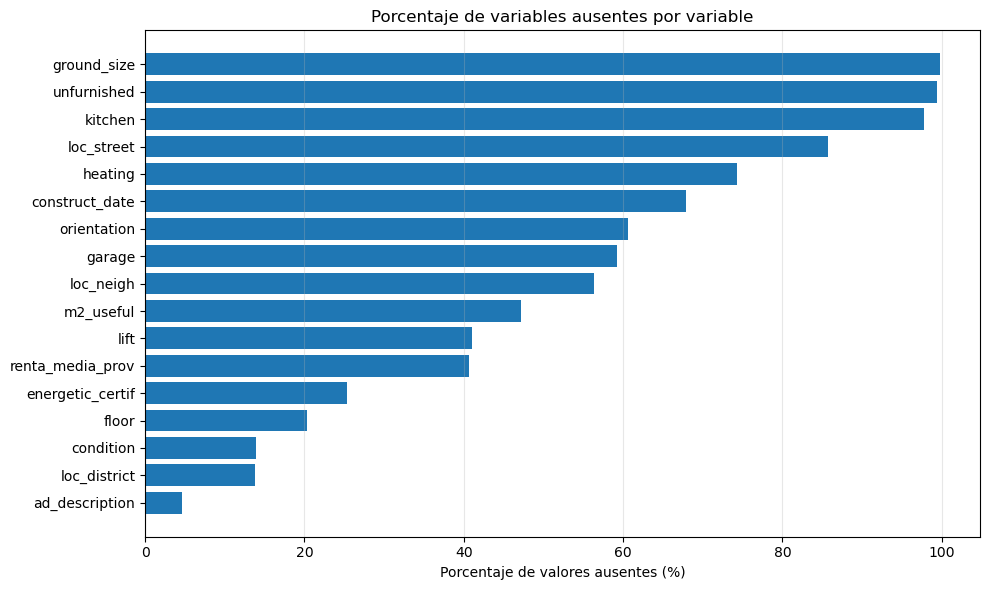

In [42]:
# Visualización de los valores ausentes

missing_percent = missing_summary["porcentaje_missing"]
missing_plot = missing_percent[missing_percent > 0].sort_values()

plt.figure(figsize=(10,6))
plt.barh(missing_plot.index, missing_plot.values)

plt.xlabel("Porcentaje de valores ausentes (%)")
plt.title("Porcentaje de variables ausentes por variable")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Comprobamos si hay alguna fila con todos sus valores nulos
df.isnull().all(axis=1).sum()

0

In [46]:
# Descripción de número de nulos por fila
df.isnull().sum(axis=1).describe()

count    100000.000000
mean          9.077450
std           2.437743
min           0.000000
25%           7.000000
50%           9.000000
75%          11.000000
max          16.000000
dtype: float64

De esta última celda, podemos obtener conclusiones interesantes: en promedio, cada fila tiene aproximadamente 9 valores nulos, la fila con más datos faltantes tiene 16 valores nulos, el 75% de las filas tiene 11 o menos nulos.

In [50]:
missing_por_fila = df.isnull().sum(axis=1)

print("Registros sin valores ausentes:", (missing_por_fila == 0).sum())
print("Registros con más de 10 valores ausentes:", (missing_por_fila > 10).sum())
print("Registros con más de 15 valores ausentes:", (missing_por_fila > 15).sum())

Registros sin valores ausentes: 87
Registros con más de 10 valores ausentes: 27997
Registros con más de 15 valores ausentes: 160


### Conclusiones

La auditoría de los valores ausentes muestra una elevada heterogeneidad en la disponibilidad de las variables del dataset. Algunas presentan porcentajes de ausencia muy elevados, como se puede apreciar en el gráfico. Por lo tanto, la ausencia de información constituye un aspecto relevante deel conjunto de datos y deberá ser considerada durante las etapas posteriores del proyecto.

A nivel de registros, no se identificaron viviendas completamente vacías. Cada registro contiene, en promedio, 9 valores ausentes, con una mediana de 9 y un rango entre 0 y 16 valores faltantes por registro.

En esta fase no se adoptan todavía decisiones sobre la eliminación o imputación de los valores faltantes, ya que su tratamiento dependerá de la naturaleza de cada variable y de su relevancia para la predicción del precio de la vivienda. Estas decisiones se abordarán posteriormente durante el análisis exploratorio y el preprocesado de datos.

## 4. Distribución básica de las variables


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas: ", len(numeric_cols))
print("Variables categóricas: ", len(categorical_cols))

Variables numéricas:  5
Variables categóricas:  36


In [55]:
# Variables categóricas - vamos a ver el número de categorías de cada una
categorical_cardinality = df[categorical_cols].nunique(dropna=True).sort_values(ascending=False)
categorical_cardinality

house_id             94524
ad_description       86150
loc_full             49369
loc_district         23068
loc_neigh            17061
loc_street            9901
price                 5712
m2_real               3710
m2_useful             1168
loc_city              1139
ad_last_update         369
construct_date         355
garage                 164
loc_zone                95
floor                   87
room_num                36
house_type              32
bath_num                30
heating                 19
orientation             16
obtention_date          14
lift                     5
energetic_certif         4
condition                4
kitchen                  3
garden                   3
chimney                  3
built_in_wardrobe        3
balcony                  3
reduced_mobility         3
air_conditioner          3
storage_room             3
swimming_pool            3
terrace                  3
unfurnished              3
ground_size              1
dtype: int64

In [58]:
# Variables numéricas
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_companies_prov,100000.0,1.000503e+05,1.144366e+05,5689.000,49582.000,75628.00,96638.00,538917.00
population_prov,100000.0,1.320589e+06,1.379332e+06,88600.000,720592.000,1128908.00,1149628.00,6578079.00
companies_prov_vs_national_%,100000.0,3.000553e+00,3.429043e+00,0.170,1.490,2.27,2.90,16.15
population_prov_vs_national_%,100000.0,2.827112e+00,2.952647e+00,0.190,1.540,2.42,2.46,14.08
renta_media_prov,59280.0,1.186435e+04,9.980435e+03,21.613,22.822,19818.00,19818.00,21714.00


### Conclusiones del análisis de la distribución de las variables

Al igual que pasaba con el análisis de valores ausentes, el análisis de cardinalidad también presenta una elevada heterogeneidad en el conjunto de datos. Algunas variables presentan un número reducido de categorías por lo que podrán analizarse como variables categóricas tras realizar las transformaciones necesarias.

Por el contrario, otras variables presentan una cardinalidad muy elevada. Destacan `house_id`, `ad_description` y las variables relacionadas con la localización, como `loc_full`, `loc_district`, `loc_neigh` y `loc_street`.

Asimismo, se observa que variables como `price`, `m2_real` y `m2_useful` presentan un elevado número de valores distintos a pesar de estar almacenadas inicialmente como variables de tipo `object`. Esto confirma lo observado en la auditoría anterior y hace más notable la necesidad de transformar determinadas variables a formatos numéricos durante el preprocesado.

En cuanto a las variables numéricas identificadas inicialmente por el conjunto de datos, se observa una importante variabilidad en las variables socioeconómicas y demográficas. Tanto `number_of_companies_prov` como `population_prov` presentan diferencias considerables entre sus valores mínimos y máximos. Del mismo modo, las variables expresadas como porcentajes muestran una dispersión apreciable entre las distintas provincias.

Por último, `renta_media_prov` presenta un porcentaje significativo de valores ausentes, aspecto que deberá tenerse en cuenta durante el análisis y el posterior preprocesado. Además, los valores observados presentan una distribución que deberá estudiarse con mayor detalle durante el EDA para determinar posibles valores atípicos o inconsistencias.

En conjunto, este análisis inicial muestra que la estructura original del dataset requiere una transformación previa antes de su utilización en los modelos predictivos. En particular, será necesario distinguir entre variables identificativas, categóricas y cuantitativas, transformar las variables numéricas almacenadas como texto y analizar de forma específica las variables de elevada cardinalidad y las relacionadas con la localización.

## 5. Comprobaciones de calidad de datos

### 5.1. Valores sospechosos

Además de los valores ausentes, se comprueba la existencia de valores que, aunque no sean nulos, puedan indicar errores de carga, problemas de formato o registros anómalos.
Se presta especial atención a aquellas variables en las que aparecen valores que coinciden con el nombre de la propia columna, ya que podrían corresponder a registros defectuosos del conjunto de datos.

In [15]:
suspicious_cols = ["ad_description", "ground_size", "house_id", "loc_street", "unfurnished"]

for col in suspicious_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(df[col].value_counts(dropna=False).head(10))


ad_description
ad_description
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [60]:
for col in suspicious_cols:
    n_suspicious = df[col].eq(col).sum()
    print(f"{col}: {n_suspicious} registros con valor igual al nombre de la columna")

ad_description: 183 registros con valor igual al nombre de la columna
ground_size: 183 registros con valor igual al nombre de la columna
house_id: 183 registros con valor igual al nombre de la columna
loc_street: 183 registros con valor igual al nombre de la columna
unfurnished: 183 registros con valor igual al nombre de la columna


#### Conclusión

La comprobación de valores sospechosos revela la existencia de 183 registros en los que determinadas variables contienen literalmente el nombre de la propia columna como valor. Este patrón aparece en variables como `ad_description`, `ground_size`, `house_id`, `loc_street` y `unfurnished`, lo que sugiere una anomalía de carga o de estructuración de los datos.

Estos valores no representan información válida de las viviendas y, por tanto, no deben considerarse categorías reales durante el análisis. Los registros afectados se mantendrán identificados durante la auditoría y su tratamiento se definirá posteriormente en la fase de preprocesado.

### 5.2. Variables numéricas almacenadas como texto

In [63]:
numeric_as_text = ["bath_num", "construct_date", "m2_real", "m2_useful", "price", "room_num"]

for col in numeric_as_text:
    print(f"\n{col}")
    print("Valores únicos:", df[col].nunique(dropna=True))
    print("Ejemplos:", df[col].dropna().unique()[:15])


bath_num
Valores únicos: 30
Ejemplos: ['2' '3' '1' '4' '7' '6' '15' '5' 'sin baños' '8' '10' '34' '11' '9' '38']

construct_date
Valores únicos: 355
Ejemplos: ['2006.0' '1998.0' '1982.0' '2005.0' '1890.0' '1971.0' '2008.0' '2000.0'
 '2009.0' '2018.0' '2011.0' '1800.0' '1988.0' '1991.0' '2002.0']

m2_real
Valores únicos: 3710
Ejemplos: ['1000' '86' '3000' '76' '100' '800' '82' '240' '4324' '600' '1350' '70'
 '552' '220' '90']

m2_useful
Valores únicos: 1168
Ejemplos: ['172.0' '74.0' '273.0' '80.0' '210.0' '243.0' '200.0' '300.0' '180.0'
 '193.0' '137.0' '215.0' '97.0' '68.0' '184.0']

price
Valores únicos: 5712
Ejemplos: ['310000' '139000' '480000' '150000' '90000' '545000' '195000' '350000'
 '499000' '595000' '447500' '330000' '70000' '423000' '320000']

room_num
Valores únicos: 36
Ejemplos: ['4' '3' '2' '7' '5' '1' '8' '13' 'sin habitación' '6' '9' '10' '15' '12'
 '30']


In [67]:
for col in numeric_as_text:
    # Si encuentra un valor que no puede convertir a número lo convierte a NaN
    converted = pd.to_numeric(df[col], errors="coerce")
    # Buscamos los valores que no eran vacíos y no puedieron convertirse a número
    non_numeric = df[col].notna() & converted.isna()

    print(f"\n{'='*50}")
    print(col)
    print("Valores no numéricos:", non_numeric.sum())

    if non_numeric.sum() > 0:
        print("Valores detectados:")
        # Vemos los registros de la columna col que no son números, contamos cuantas veces aparece cada valor
        print(df.loc[non_numeric, col].value_counts())


bath_num
Valores no numéricos: 853
Valores detectados:
bath_num
sin baños    670
bath_num     183
Name: count, dtype: int64

construct_date
Valores no numéricos: 183
Valores detectados:
construct_date
construct_date    183
Name: count, dtype: int64

m2_real
Valores no numéricos: 183
Valores detectados:
m2_real
m2_real    183
Name: count, dtype: int64

m2_useful
Valores no numéricos: 183
Valores detectados:
m2_useful
m2_useful    183
Name: count, dtype: int64

price
Valores no numéricos: 183
Valores detectados:
price
price    183
Name: count, dtype: int64

room_num
Valores no numéricos: 1438
Valores detectados:
room_num
sin habitación    1255
room_num           183
Name: count, dtype: int64


### Conclusiones

La auditoría confirma que varias variables de naturaleza cuantitativa se encuentran almacenadas inicialmente como texto (`object`). En concreto: `bath_num`, `construct_date`, `m2_real`, `m2_useful`, `price` y `room_num` presentan valores que corresponden a variables numéricas, por lo que deberán ser transformadas durante el preprocesado.

No obstante, la conversión no puede realizarse de forma completamente automática en todas las variables. `bath_num` y `room_num` contienen categorías textuales como `sin baños` y `sin habitación`, mientras que `construct_date` presenta años almacenados con formato decimal. Además, en algunas de estas variables aparecen valores que coinciden con el nombre de la propia columna, identificados previamente como registros sospechosos.

Por tanto, se establece como decisión de preprocesado la conversión de estas variables a formatos numéricos.

### 5.3. Registros duplicados

Se comprueba la existencia de registros duplicados en el conjunto de datos. En primer lugar, se identifican aquellas filas que presentan exactamente los mismos valores en todas sus variables.

La existencia de valores repetidos en determinadas variables, como el identificador del inmueble (`house_id`), se analizará de forma independiente en el apartado siguiente, ya que varios registros asociados a un mismo inmueble no implican necesariamente que se trate de duplicados exactos.

In [75]:
# Número de registros duplicados exactos

duplicate_count = df.duplicated().sum()

print("Número de registros duplicados:", duplicate_count)
print("Porcentaje de duplicados:", round(duplicate_count / len(df) * 100, 2), "%")

Número de registros duplicados: 168
Porcentaje de duplicados: 0.17 %


In [119]:
duplicates = df[df.duplicated(keep=False)]
print("Registros pertenecientes a grupos duplicados: ", len(duplicates))

Registros pertenecientes a grupos duplicados:  184


Esto es distinto que duplicate_count, ya que al usar el parámetro keep=false, se muestran todas las filas pertenecientes al grupo duplicado, y sin parámetro, muestra 168 en vez de 184. Los 168 son los registros que se eliminarían (se dejaría la primera aparición de cada registro repetido, de ahí la diferencia).

### Conclusiones

La auditoría identifica 168 registros duplicados de forma exacta, lo que representa un 0,17 % del total de observaciones. Aunque su presencia es reducida, estos registros no aportan información adicional al conjunto de datos y podrían introducir un peso innecesario de determinadas observaciones durante el análisis y el posterior entrenamiento de los modelos.

Por este motivo, se considera adecuado eliminar los duplicados exactos durante la fase de preprocesado, manteniendo una única aparición de cada registro. 

### 5.4. Valores de `house_id` repetidos.

La variable `house_id` se utiliza como identificador de la vivienda dentro del dataset. Por este motivo, se va a comprobar si existen diferentes registros asociados a un mismo identificador.

La presencia de identificadores repetidos no implica necesariamente que los registros sean duplicados, ya que pueden existir diferentes observaciones correspondientes a un mismo inmueble. Por ello, se analiza tanto el número de identificadores únicos y repetidos como la distribución de su frecuencia de aparición. 

In [83]:
# Número de identificadores únicos
unique_house_ids = df["house_id"].nunique(dropna=True)

print("Número de house_id únicos: ", unique_house_ids)
print("Número de registros que no tienen un house_id único: ", len(df) - unique_house_ids)


Número de house_id únicos:  94524
Número de registros que no tienen un house_id único:  5476


In [84]:
# Frecuencia de aparición de cada house_id
house_id_counts = df["house_id"].value_counts(dropna=False)

# Identificadores que aparecen más de una vez
repeated_house_ids = house_id_counts[house_id_counts > 1]

print("Número de house_id repetidos: ", len(repeated_house_ids))
print("Número de registros asociados a house_id repetidos: ", repeated_house_ids.sum())

Número de house_id repetidos:  5295
Número de registros asociados a house_id repetidos:  10771


In [85]:
repeated_house_ids.value_counts().sort_index()

count
2      5294
183       1
Name: count, dtype: int64

La mayoría de los house_id repetidos aparecen 2 veces, mientras que hay un caso especial con 183 apariciones (los registros cuyo valor es el propio nombre de la variable).

In [104]:
# Inspección de algunos identificadores repetidos

top_repeated_ids = repeated_house_ids.head(10).index

df[df["house_id"].isin(top_repeated_ids)][
    ["house_id", "price", "m2_real", "m2_useful","house_type", "loc_city", "loc_full"]
].sort_values("house_id")

,house_id,price,m2_real,m2_useful,house_type,loc_city,loc_full
40316,26731618,385000,165,NaN,Dúplex,Leioa,"Calle Sarriena Auzoa, 47 , Distrito Aldekoena..."
57125,26731618,385000,165,NaN,Dúplex,Leioa,"Calle Sarriena Auzoa, 47 , Distrito Aldekoena..."
37509,81297212,300000,110,95.0,Piso,Bakio,"benta alde, 61 , Bakio , Uribe-Butroe, Vizcaya"
55152,81297212,300000,110,95.0,Piso,Bakio,"benta alde, 61 , Bakio , Uribe-Butroe, Vizcaya"
40318,81786389,419000,180,170.0,Dúplex,Leioa,", Distrito Centro Urbano-Hirigunea , Leioa , ..."
...,...,...,...,...,...,...,...
31628,house_id,price,m2_real,m2_useful,house_type,loc_city,loc_full
32115,house_id,price,m2_real,m2_useful,house_type,loc_city,loc_full
32794,house_id,price,m2_real,m2_useful,house_type,loc_city,loc_full
32996,house_id,price,m2_real,m2_useful,house_type,loc_city,loc_full


#### Conclusiones

La variable `house_id` presenta 94.524 valores distintos en los 100.000 registros del conjunto de datos. Se identifican 5.295 identificadores que aparecen en más de un registro, asociados a un total de 10.771 observaciones. La distribución de las repeticiones muestra que 5.294 identificadores aparecen exactamente dos veces, mientras que un identificador presenta 183 apariciones.

La existencia de house_id repetidos no implica por sí misma que se trate de duplicados exactos. La comprobación anterior ha permitido identificar 168 duplicados completos, mientras que otros registros comparten identificador sin que necesariamente coincidan en todas sus variables. Por ello, ambas situaciones se tratarán de forma diferenciada.

En consecuencia, `house_id` no se considerará inicialmente una variable predictora del precio, sino un identificador del registro. Las decisiones definitivas sobre la eliminación de los registros anómalos y sobre la estrategia de división de los datos se establecerán durante las etapas de preprocesado y modelado.

### 5.5. Variables binarias

Se analizan las variables que representan la presencia o ausencia de determinadas características, como aire acondicionado, balcón, jardín o piscina. El objetivo es comprobar los valores que presentan estas variables y detectar posibles valores anómalos antes de su transformación durante el preprocesado.

In [120]:
# Variables binarias

binary_candidates = ["air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "lift",
    "reduced_mobility",
    "storage_room",
    "swimming_pool",
    "terrace"
]

for col in binary_candidates:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))



air_conditioner
air_conditioner
0                  76867
1                  22950
air_conditioner      183
Name: count, dtype: int64

balcony
balcony
0          81668
1          18149
balcony      183
Name: count, dtype: int64

built_in_wardrobe
built_in_wardrobe
0                    57444
1                    42373
built_in_wardrobe      183
Name: count, dtype: int64

chimney
chimney
0          96132
1           3685
chimney      183
Name: count, dtype: int64

garden
garden
0         71992
1         27825
garden      183
Name: count, dtype: int64

lift
lift
NaN     41035
1       23809
1.0     14734
0       13491
0.0      6748
lift      183
Name: count, dtype: int64

reduced_mobility
reduced_mobility
0                   91753
1                    8064
reduced_mobility      183
Name: count, dtype: int64

storage_room
storage_room
0               58759
1               41058
storage_room      183
Name: count, dtype: int64

swimming_pool
swimming_pool
0                81425
1             

#### Conclusiones

Las variables analizadas presentan, en general, una estructura binaria basada en los valores `0` y `1`, correspondientes a la ausencia o presencia de la característica representada. No obstante, se detectan 183 registros anómalos en nueve de las diez variables, en los que aparece como valor el propio nombre de la columna. Esta anomalía coincide con la identificada previamente en la variable `house_id` y deberá ser tratada durante el preprocesado.

La variable `lift` presenta además una codificación ligeramente diferente, ya que combina los valores `0` y `1` con sus representaciones decimales `0.0` y `1.0`, además de valores ausentes. Por tanto, será necesario normalizar estas representaciones antes de convertir las variables a un formato numérico binario.

En consecuencia, estas variables podrán ser consideradas como variables binarias durante el modelado, previa limpieza y normalización de sus valores durante la etapa de preprocesado.

### 5.6. Variable renta_media_prov

La variable `renta_media_prov` representa la renta media de la provincia asociada a cada vivienda y constituye una variable socioeconómica potencialmente relevante para la estimación del precio. Durante la auditoría se analiza su distribución para detectar posibles problemas de formato, escalas inconsistentes o valores anómalos que puedan afectar posteriormente al modelado.



In [25]:
print(df["renta_media_prov"].value_counts(dropna=False).head(20))


renta_media_prov
NaN          40720
19818.000    23197
22.803        8341
21714.000     7705
29.400        5255
19889.000     3806
22.822        2867
22.221        2652
21.613        1946
23.532        1404
22.339        1222
28.514         885
Name: count, dtype: int64


In [107]:
df["renta_media_prov"].describe()

count    59280.00000
mean     11864.35119
std       9980.43530
min         21.61300
25%         22.82200
50%      19818.00000
75%      19818.00000
max      21714.00000
Name: renta_media_prov, dtype: float64

In [111]:
df["renta_media_prov"].dropna().sort_values().head(10)

8759    21.613
8915    21.613
8916    21.613
8917    21.613
8918    21.613
8919    21.613
8920    21.613
8921    21.613
8922    21.613
8923    21.613
Name: renta_media_prov, dtype: float64

In [112]:
df["renta_media_prov"].dropna().sort_values().tail(10)

75267    21714.0
75268    21714.0
75269    21714.0
75270    21714.0
75271    21714.0
75272    21714.0
75273    21714.0
75274    21714.0
75185    21714.0
75196    21714.0
Name: renta_media_prov, dtype: float64

In [113]:
renta = df["renta_media_prov"]

print("Valores < 100:", (renta < 100).sum())
print("Valores >= 100:", (renta >= 100).sum())
print("Valores nulos:", renta.isna().sum())

Valores < 100: 24572
Valores >= 100: 34708
Valores nulos: 40720


In [117]:
# Provincias con valores menores de 100

df.loc[df["renta_media_prov"] < 100,["renta_media_prov", "loc_zone", "loc_city"]
].drop_duplicates().sort_values("renta_media_prov").head(20)

,renta_media_prov,loc_zone,loc_city
8275,21.613,"Alt Vinalopó, Alicante",Villena
8279,21.613,"Alt Vinalopó, Alicante",Sax
8280,21.613,"Alt Vinalopó, Alicante",Biar
8283,21.613,"Alt Vinalopó, Alicante",Salinas
8288,21.613,"Alt Vinalopó, Alicante",Campo de Mirra
8297,21.613,"Alt Vinalopó, Alicante",Cañada
8302,21.613,"Alt Vinalopó, Alicante",Benejama
9446,21.613,loc_zone,loc_city
9447,21.613,"Vinalopó Mitjà, Alicante",Pinoso
9537,21.613,"Marina Baixa, Alicante",La Nucia


In [115]:
# Provincias con valores mayores de 100

df.loc[df["renta_media_prov"] >= 100,["renta_media_prov", "loc_zone", "loc_city"]
].drop_duplicates().sort_values("renta_media_prov").head(20)

,renta_media_prov,loc_zone,loc_city
49196,19818.0,"Gran Bilbao, Vizcaya",Abanto y Ciérvana/Abanto Zierbena
38414,19818.0,"Lea-Artibai, Vizcaya",Munitibar-Arbatzegi Gerrikaitz
38413,19818.0,"Lea-Artibai, Vizcaya",Markina-Xemein
38411,19818.0,"Lea-Artibai, Vizcaya",Amoroto
38410,19818.0,"Lea-Artibai, Vizcaya",Ziortza-Bolibar
38406,19818.0,"Lea-Artibai, Vizcaya",Ondarroa
38405,19818.0,"Lea-Artibai, Vizcaya",Lekeitio
38404,19818.0,"Lea-Artibai, Vizcaya",Berriatua
36916,19818.0,"Uribe-Butroe, Vizcaya",Gamiz-Fika
36885,19818.0,"Uribe-Butroe, Vizcaya",Meñaka


### Conclusiones

La variable `renta_media_prov` presenta un porcentaje elevado de valores ausentes, con 40.720 registros sin información (40,72 % del conjunto).

Entre los 59.280 valores disponibles se observa una distribución muy concentrada en determinados valores. Además, 24.572 registros presentan valores inferiores a 100, mientras que 34.708 presentan valores iguales o superiores a 100. El análisis de su distribución geográfica muestra que estos valores inferiores a 100 aparecen asociados a distintas zonas.

Esta aparente anomalía se debe probablemente a una **diferencia en la escala o en el formato de representación de los valores**: por ejemplo, valores como `21.613` parecen corresponder a rentas del orden de 21.613 €, y no a valores monetarios de 21,613 €. Por tanto, el punto decimal parece estar actuando como separador de miles en parte de los registros.

En consecuencia, `renta_media_prov` se conservará inicialmente como variable potencialmente relevante, pero será necesario **homogeneizar su escala durante el preprocesado** antes de utilizarla en el EDA y en el modelado.

## 6. Resumen de la auditoría

La auditoría inicial del conjunto de datos permite identificar varios aspectos relevantes que deberán tenerse en cuenta durante las etapas posteriores de preparación y análisis.

- El conjunto contiene **100.000 registros y 41 variables**. La clasificación inicial de Pandas identifica 36 variables como `object` y únicamente 5 como numéricas. Esta clasificación no refleja completamente la naturaleza de las variables, ya que algunas variables cuantitativas se encuentran almacenadas como texto.

- Se detectan **17 variables con valores ausentes**, algunas con porcentajes muy elevados, por lo que el tratamiento deberá realizarse de forma individual.

- Se han identificado **valores sospechosos** en determinadas variables, principalmente registros en los que aparece literalmente el nombre de la propia columna. Se trata de 183 registros asociados a una estructura defectuosa del dataset, por lo que deberán tratarse como valores no válidos durante el preprocesado.

- Varias variables cuantitativas, como `bath_num`, `construct_date`, `m2_real`, `m2_useful`, `price` y `room_num`, están almacenadas como texto. Además, algunas contienen valores textuales como `sin baños` o `sin habitación`, que deberán ser tratados antes de realizar conversiones numéricas.

- Se detectan **168 registros completamente duplicados**, equivalentes al 0,17 % del conjunto. Su reducido peso sobre el total no quita la necesidad de eliminarlos para evitar que determinadas observaciones tengan un peso artificialmente superior.

- La variable `house_id` presenta **94.524 identificadores únicos frente a 100.000 registros**. Existen identificadores repetidos y, además, 183 registros contienen literalmente `house_id` como valor. La repetición de identificadores no implica necesariamente que todos los registros sean duplicados exactos, por lo que deberá diferenciarse entre duplicados completos y anuncios que comparten identificador.

- Las variables de tipo binario presentan principalmente los valores `0` y `1`, aunque algunas contienen valores anómalos correspondientes al nombre de la propia variable. `lift`, además, presenta distintas representaciones de los valores binarios (`0`, `1`, `0.0`, `1.0`) y valores ausentes.

- La variable `renta_media_prov` presenta un **40,72 % de valores ausentes** y una inconsistencia aparente en la escala de algunos valores. Los valores inferiores a 100 parecen corresponder a una representación incorrecta de cantidades expresadas en miles de euros, por lo que esta hipótesis deberá verificarse durante el preprocesado.

En conjunto, la auditoría muestra que el dataset es aprovechable, pero requiere una fase de preprocesado específica antes de realizar el análisis exploratorio definitivo. Las principales actuaciones serán: corrección de valores anómalos, conversión de variables cuantitativas almacenadas como texto, tratamiento de duplicados, normalización de variables binarias y revisión de `renta_media_prov`.

## 7. Decisiones para el preprocesado

A partir de los resultados obtenidos en la auditoría, se establecen las siguientes decisiones iniciales para la preparación del conjunto de datos:

1. **Valores anómalos**
   
   Los registros en los que aparece el nombre de la propia variable como valor se considerarán valores no válidos y se transformarán en valores ausentes (`NaN`) antes de continuar con el análisis.

2. **Variables numéricas almacenadas como texto**
   
   Las variables `bath_num`, `construct_date`, `m2_real`, `m2_useful`, `price` y `room_num` serán transformadas a tipos numéricos. Los valores textuales que representen ausencia de información, como `sin baños` o `sin habitación`, se tratarán como valores ausentes.

3. **Variables binarias**
   
   Las variables binarias se normalizarán a una representación homogénea de `0` y `1`. Se corregirán las distintas representaciones existentes y los valores anómalos serán tratados como ausentes.

4. **Registros duplicados**
   
   Los 168 registros completamente duplicados serán eliminados para evitar que las mismas observaciones tengan un peso superior durante el análisis.

5. **`house_id`**
   
   Los valores de `house_id` se conservarán inicialmente como identificadores y no como variable predictora. Los registros con identificadores repetidos serán analizados con precaución, diferenciando entre duplicados completos y posibles anuncios diferentes asociados al mismo identificador.

6. **Valores ausentes**
   
   No se aplicará una estrategia única de imputación a todas las variables. El tratamiento de los valores ausentes se decidirá posteriormente en función de la naturaleza de cada variable, su porcentaje de ausencia y su relevancia para el análisis.

7. **`renta_media_prov`**
   
   Se revisará y corregirá la escala de los valores de `renta_media_prov` antes de utilizar esta variable. Una vez homogeneizada su representación, se evaluará nuevamente su distribución y porcentaje de valores ausentes para decidir su tratamiento definitivo.

Estas decisiones constituyen el punto de partida del preprocesado. Las transformaciones se realizarán de forma controlada sobre una copia del dataset original, manteniendo el conjunto de datos bruto sin modificaciones para garantizar la trazabilidad del proceso.